In [1]:
import pandas as pd
import optuna
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, roc_auc_score
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
import matplotlib as mpl
from matplotlib import font_manager
import math

pd.set_option('display.max_columns', None)
data_path = '/data/home/yansn/naojiye/data/final_data/filtered_patient2.csv'
filtered_df = pd.read_csv(data_path)
filtered_df.shape

/data/home/yansn/anaconda3/envs/naojiye/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(887, 232)

In [2]:
columns_to_change1 = [item for item in filtered_df if item.endswith('_定性')]
columns_to_change2 = [item for item in filtered_df if item.endswith('_描述性')]

# 对每个object类型的列进行Label Encoding
object_columns = columns_to_change1+columns_to_change2
if 'filtered_patient1' in data_path or 'filtered_patient2' in data_path or 'filtered_patient5' in data_path:
    object_columns.remove('脑脊液_透明度_描述性')
    object_columns.remove('脑脊液_肿瘤细胞_描述性')
    object_columns.remove('脑脊液_蛋白定性_定性')


features_to_change = ['血_隐球菌荚膜抗原_定性', '血_抗双链DNA抗体_定性', '血_抗核抗体_定性', '血_抗胞浆型中性粒细胞抗体_定性', '血_抗核周型中性粒细胞抗体_定性', '血_梅毒非特异性抗体_定性', '血_梅毒螺旋体抗体_定性',
                       '血_人类免疫缺陷病毒抗体_定性', '血_不规则抗体_定性', '血_直接抗人球蛋白试验_定性', '血_结核感染T细胞检测_定性', '血_人类免疫缺陷病毒P24抗原_定性', '血_M蛋白_描述性']

if 'filtered_patient2' in data_path or 'filtered_patient4' in data_path:
    for i in features_to_change:
        object_columns.remove(i)

le_dict = {}
for col in object_columns:
    le = LabelEncoder()
    filtered_df[col] = le.fit_transform(filtered_df[col].astype(str))  # 确保没有NaN，否则会报错
    le_dict[col] = le  # 保存编码器，后续可能用于推理


In [3]:

# 替换特征名中的 [，]
def clean_feature_names_simple(feature_names):
    cleaned_names = []
    for name in feature_names:
        cleaned_name = name.replace('[', '').replace(']', '').replace('<', '').replace('>', '')
        cleaned_names.append(cleaned_name)
    return cleaned_names

# 对 DataFrame 的列名进行清洗
filtered_df.columns = clean_feature_names_simple(filtered_df.columns)
print("清洗后的列名:", filtered_df.columns.tolist())

清洗后的列名: ['Unnamed: 0', 'patientId', '血_1,3-β-D-葡聚糖_定量', '血_隐球菌荚膜抗原_定性', '血_半乳甘露聚糖_定量', '血_细胞.CD3-CD19+百分比_定量', '血_细胞.CD3+百分比_定量', '血_细胞.CD3+CD4+百分比_定量', '血_细胞.CD4+/CD8+_定量', '血_细胞.CD3+CD8+百分比_定量', '血_细胞.CD3-CD16+CD56+百分比_定量', '血_肌酸激酶.MB型质量法_定量', '血_B型钠尿肽前体_定量', '血_肌钙蛋白T_定量', '血_肌红蛋白_定量', '血_促甲状腺激素_定量', '血_促甲状腺激素受体抗体_定量', '血_甲状腺过氧化物酶抗体_定量', '血_抗甲状腺球蛋白抗体_定量', '血_甲状腺素_定量', '血_三碘甲状腺原氨酸_定量', '血_游离T4_定量', '血_游离T3_定量', '血_降钙素原_定量', '血_铁蛋白_定量', '血_D-二聚体_定量', '血_活化部分凝血活酶时间_定量', '血_凝血酶原时间国际标准化比值_定量', '血_凝血酶时间_定量', '血_凝血酶原时间_定量', '血_纤维蛋白原_定量', '血_纤维蛋白降解产物_定量', '血_肾小球滤过率_定量', '血_γ谷氨酰转肽酶_定量', '血_白蛋白_定量', '血_白蛋白/球蛋白_定量', '血_丙氨酸氨基转移酶_定量', '血_总胆固醇_定量', '血_低密度脂蛋白胆固醇_定量', '血_二氧化碳结合力_定量', '血_非高密度脂蛋白胆固醇_定量', '血_甘油三酯_定量', '血_高密度脂蛋白胆固醇_定量', '血_肌酐_定量', '血_钾_定量', '血_碱性磷酸酶_定量', '血_氯_定量', '血_钠_定量', '血_尿素_定量', '血_尿酸_定量', '血_前白蛋白_定量', '血_球蛋白_定量', '血_门冬氨酸氨基转移酶_定量', '血_磷_定量', '血_钙_定量', '血_镁_定量', '血_脂蛋白a_定量', '血_直接胆红素_定量', '血_总胆红素_定量', '血_总胆汁酸_定量', '血_总蛋白_定量', '血_葡萄糖空腹_定量', '血_腺苷脱氨酶_定量', '血_小而密脂蛋白胆固醇_定量', '血_C反应蛋白_定

In [ ]:
# 区分是否是自身免疫性脑膜炎：6是一类，012345是一类

# 1. 数据预处理：将 'gender' 列转换为数值型
filtered_df['gender'] = filtered_df['gender'].map({'女': 0, '男': 1})

# 去除病毒性脑炎（8）病状
filtered_df = filtered_df[filtered_df['分组']!=8]

# 选择特征 将数据正例和反例平均分配
filter_1 = filtered_df[filtered_df["分组"]==6]
filter_2 = filtered_df[filtered_df["分组"].isin([0,1,2,3,4,5])]

X_1 = filter_1[list(filter_1.columns)[2:-2]]
X_2 = filter_2[list(filter_2.columns)[2:-2]]

# 标签（分组，6 类与其他类）
y_1 = (filter_1['分组']==6).astype(int)# 如果分组为 6，标签为 1，否则为 0
y_2 = (filter_2['分组']==6).astype(int) 

# 拆分数据集为训练集（60%）、验证集（20%）和测试集（20%）
X_train_1, X_temp_1, y_train_1, y_temp_1 = train_test_split(X_1, y_1, test_size=0.4, random_state=42)
X_val_1, X_test_1, y_val_1, y_test_1 = train_test_split(X_temp_1, y_temp_1, test_size=0.5, random_state=42)

X_train_2, X_temp_2, y_train_2, y_temp_2 = train_test_split(X_2, y_2, test_size=0.4, random_state=42)
X_val_2, X_test_2, y_val_2, y_test_2 = train_test_split(X_temp_2, y_temp_2, test_size=0.5, random_state=42)

# 将正例与反例拼接
X_train = pd.concat([X_train_1,X_train_2])
y_train = pd.concat([y_train_1,y_train_2])

X_val = pd.concat([X_val_1,X_val_2])
y_val = pd.concat([y_val_1,y_val_2])

X_test = pd.concat([X_test_1,X_test_2])
y_test = pd.concat([y_test_1,y_test_2])


# 定义 Optuna 目标函数
def objective(trial):
    # 建议超参数范围
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'random_state': 42
    }
    
    # 创建模型
    model = xgb.XGBClassifier(**params)
    
    # 训练模型
    model.fit(X_train, y_train)
    
    # 预测验证集概率
    y_val_pred_proba = model.predict_proba(X_val)[:, 1]
    
    # 计算 AUC
    auc_score = roc_auc_score(y_val, y_val_pred_proba)
    
    # 由于 Optuna 默认最小化目标函数，我们返回 1 - AUC 来最大化 AUC
    return 1.0 - auc_score

# 创建 Optuna 研究
study = optuna.create_study(
    direction='minimize',  # 最小化目标函数 (1 - AUC)
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10)  # 10轮后开始剪枝
)

# 运行优化
print("开始超参数优化...")
study.optimize(objective, n_trials=100, show_progress_bar=True)

# 输出最佳结果
print("\n优化完成!")
print("Number of finished trials: ", len(study.trials))
print("Best trial:")
best_trial = study.best_trial
print(f"  Best AUC: {1 - best_trial.value:.4f}")  # 转换回 AUC
print("  Best params: ")
for key, value in best_trial.params.items():
    print(f"    {key}: {value}")

# 使用最佳参数重新训练最终模型
print("\n使用最佳参数训练最终模型...")
best_params = best_trial.params
best_params['random_state'] = 42

final_model = xgb.XGBClassifier(**best_params)
final_model.fit(X_train, y_train)

# 在各个数据集上评估最终模型
def evaluate_model(model, X, y, dataset_name):
    y_pred = model.predict(X)
    y_pred_proba = model.predict_proba(X)[:, 1]
    
    auc = roc_auc_score(y, y_pred_proba)
    accuracy = accuracy_score(y, y_pred)
    f1 = f1_score(y, y_pred)
    
    print(f"\n{dataset_name} 集评估结果:")
    print(f"AUC: {auc:.4f}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1-score: {f1:.4f}")
    
    # 打印混淆矩阵
    # cm = confusion_matrix(y, y_pred)
    # print("Confusion Matrix:")
    # print(cm)
    
    return auc, accuracy, f1

# 评估训练集、验证集和测试集
train_auc, train_acc, train_f1 = evaluate_model(final_model, X_train, y_train, "训练")
val_auc, val_acc, val_f1 = evaluate_model(final_model, X_val, y_val, "验证")
test_auc, test_acc, test_f1 = evaluate_model(final_model, X_test, y_test, "测试")

# 可选：保存最佳模型
# import joblib
# joblib.dump(final_model, 'best_xgb_model.pkl')
# print("\n最佳模型已保存为 'best_xgb_model.pkl'")

# 可选：绘制特征重要性
# import matplotlib.pyplot as plt

# plt.figure(figsize=(10, 8))
# xgb.plot_importance(final_model, max_num_features=15)
# plt.title('Feature Importance')
# plt.tight_layout()
# plt.show()

[I 2025-09-09 17:17:07,398] A new study created in memory with name: no-name-2541eb59-2337-44cc-b935-2ac3fbd12f17


开始超参数优化...


  0%|          | 0/100 [00:00<?, ?it/s]

Best trial: 0. Best value: 0.118177:   1%|          | 1/100 [00:33<55:55, 33.89s/it]

[I 2025-09-09 17:17:41,290] Trial 0 finished with value: 0.11817653890824609 and parameters: {'n_estimators': 200, 'max_depth': 10, 'learning_rate': 0.06504856968981275, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'reg_alpha': 2.5348407664333426e-07, 'reg_lambda': 3.3323645788192616e-08, 'min_child_weight': 9, 'gamma': 3.005575058716044}. Best is trial 0 with value: 0.11817653890824609.


...

[I 2025-09-09 17:18:17,482] Trial 1 finished with value: 0.12543554006968638 and parameters: {'n_estimators': 400, 'max_depth': 3, 'learning_rate': 0.2526878207508456, 'subsample': 0.9329770563201687, 'colsample_bytree': 0.6849356442713105, 'reg_alpha': 4.329370014459266e-07, 'reg_lambda': 4.4734294104626844e-07, 'min_child_weight': 4, 'gamma': 2.6237821581611893}. Best is trial 0 with value: 0.11817653890824609.


Best trial: 0. Best value: 0.118177:   3%|▎         | 3/100 [02:01<1:08:47, 42.55s/it]

[I 2025-09-09 17:19:08,718] Trial 2 finished with value: 0.12253193960511033 and parameters: {'n_estimators': 250, 'max_depth': 5, 'learning_rate': 0.032781876533976156, 'subsample': 0.6557975442608167, 'colsample_bytree': 0.7168578594140873, 'reg_alpha': 1.9826980964985924e-05, 'reg_lambda': 0.00012724181576752517, 'min_child_weight': 8, 'gamma': 0.9983689107917987}. Best is trial 0 with value: 0.11817653890824609.


Best trial: 0. Best value: 0.118177:   4%|▍         | 4/100 [03:06<1:22:38, 51.65s/it]

[I 2025-09-09 17:20:14,321] Trial 3 finished with value: 0.13095238095238093 and parameters: {'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.0013033567475147442, 'subsample': 0.8430179407605753, 'colsample_bytree': 0.6682096494749166, 'reg_alpha': 3.850031979199519e-08, 'reg_lambda': 3.4671276804481113, 'min_child_weight': 10, 'gamma': 4.041986740582305}. Best is trial 0 with value: 0.11817653890824609.


matplotlib 识别的字体名: Songti SC
Validation Set Performance:
Accuracy: 0.8278
Precision: 0.7500
Recall: 0.1071
F1-Score: 0.1875

Test Set Performance:
Accuracy: 0.8355
Precision: 0.6667
Recall: 0.2143
F1-Score: 0.3243


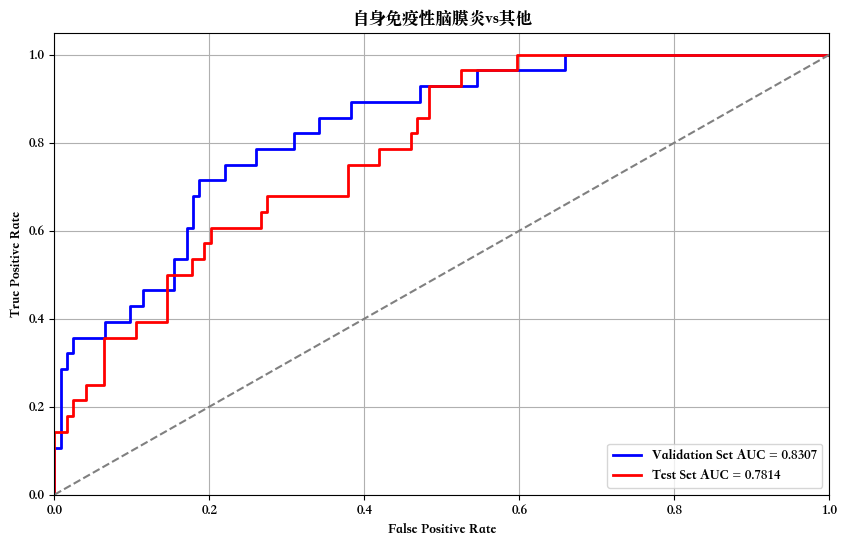

[0.8278, 0.75, 0.1071, 0.1875, 0.8307, 0.8355, 0.6667, 0.2143, 0.3243, 0.7814]

In [5]:
#注册中文字体到matplotlib
font_path = "/data/home/yansn/anaconda3/envs/naojiye/lib/python3.10/site-packages/matplotlib/mpl-data/fonts/ttf/Songti.ttc"
mpl.font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path)
font_name = prop.get_name()
print("matplotlib 识别的字体名:", font_name)

plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False


# 预测验证集和测试集
y_val_pred = final_model.predict(X_val)
y_test_pred = final_model.predict(X_test)

# 预测验证集和测试集的概率（用于绘制 AUC 曲线）
y_val_prob = final_model.predict_proba(X_val)[:, 1]
y_test_prob = final_model.predict_proba(X_test)[:, 1]

# 计算准确率、精确率、召回率和F1分数
val_accuracy = accuracy_score(y_val, y_val_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

val_precision = precision_score(y_val, y_val_pred)
test_precision = precision_score(y_test, y_test_pred)

val_recall = recall_score(y_val, y_val_pred)
test_recall = recall_score(y_test, y_test_pred)

val_f1 = f1_score(y_val, y_val_pred)
test_f1 = f1_score(y_test, y_test_pred)

# 输出模型评估结果
print("Validation Set Performance:")
print(f"Accuracy: {val_accuracy:.4f}")
print(f"Precision: {val_precision:.4f}")
print(f"Recall: {val_recall:.4f}")
print(f"F1-Score: {val_f1:.4f}")

print("\nTest Set Performance:")
print(f"Accuracy: {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall: {test_recall:.4f}")
print(f"F1-Score: {test_f1:.4f}")

# 绘制 ROC 曲线和 AUC
fpr_val, tpr_val, _ = roc_curve(y_val, y_val_prob)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_prob)

# 计算 AUC
roc_auc_val = auc(fpr_val, tpr_val)
roc_auc_test = auc(fpr_test, tpr_test)

# 绘制 ROC 曲线
plt.figure(figsize=(10, 6))
plt.plot(fpr_val, tpr_val, color='blue', lw=2, label=f'Validation Set AUC = {roc_auc_val:.4f}')
plt.plot(fpr_test, tpr_test, color='red', lw=2, label=f'Test Set AUC = {roc_auc_test:.4f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # 对角线
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('自身免疫性脑膜炎vs其他')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

[round(val_accuracy,4),round(val_precision,4),round(val_recall,4),round(val_f1,4),round(roc_auc_val,4),round(test_accuracy,4),round(test_precision,4),round(test_recall,4),round(test_f1,4),round(roc_auc_test,4)]


===== SHAP 特征重要性 (柱状图):  =====


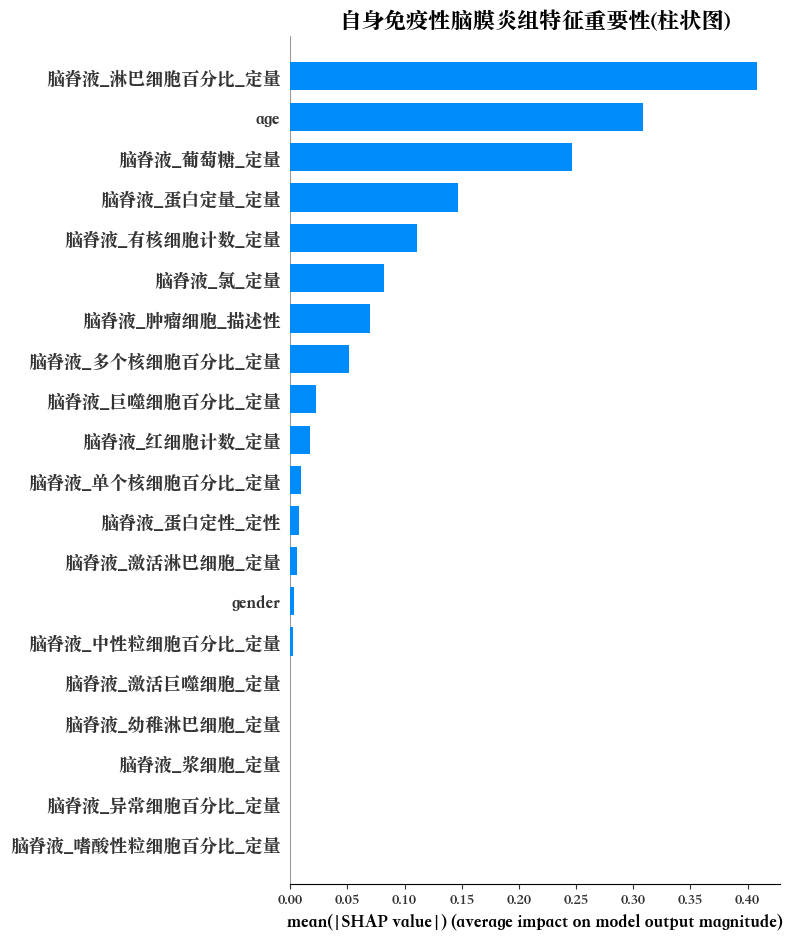


===== SHAP 特征分布 (蜂群图): =====


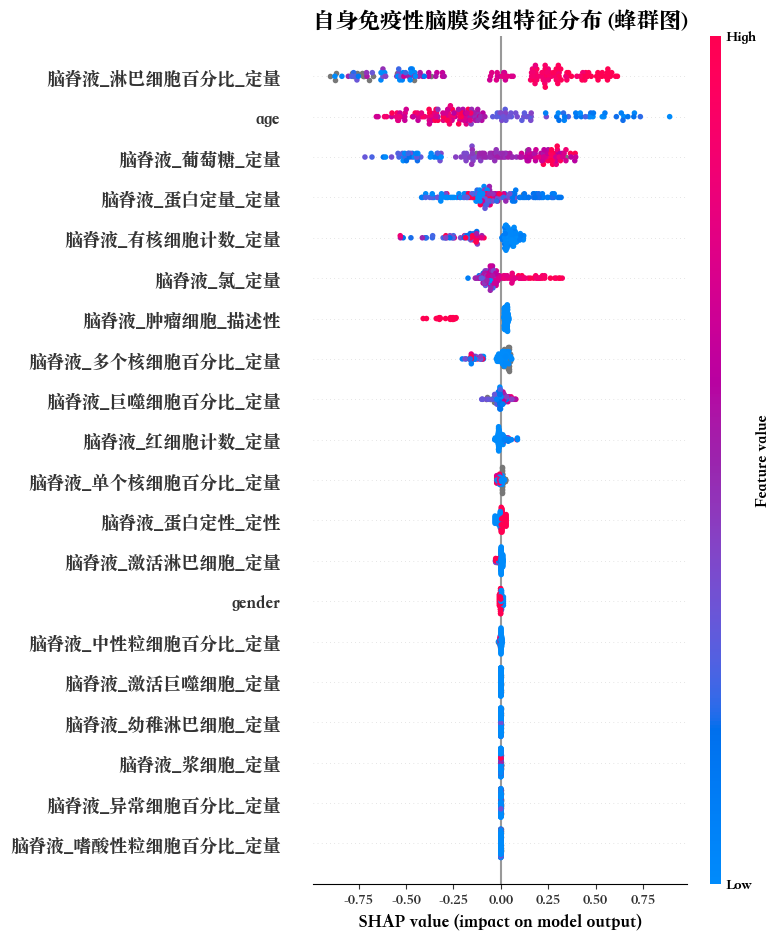

In [6]:

# ---------------- SHAP 分析 -----------------
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)
shap_matrix = shap_values[1] if isinstance(shap_values, list) else shap_values

print(f"\n===== SHAP 特征重要性 (柱状图):  =====")
plt.title("自身免疫性脑膜炎组特征重要性(柱状图)", fontsize=16, fontweight='bold')
plt.tight_layout()
shap.summary_plot(shap_matrix, X_test, plot_type="bar", show=True)
plt.title("自身免疫性脑膜炎组特征分布 (蜂群图)", fontsize=16, fontweight='bold')
plt.tight_layout()

print(f"\n===== SHAP 特征分布 (蜂群图): =====")
shap.summary_plot(shap_matrix, X_test, show=True)


/data/home/yansn/anaconda3/envs/naojiye/lib/python3.10/site-packages/shap/plots/_waterfall.py:279: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Songti SC.
  text_bbox = txt_obj.get_window_extent(renderer=renderer)


/data/home/yansn/anaconda3/envs/naojiye/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Songti SC.
  fig.canvas.print_figure(bytes_io, **kw)


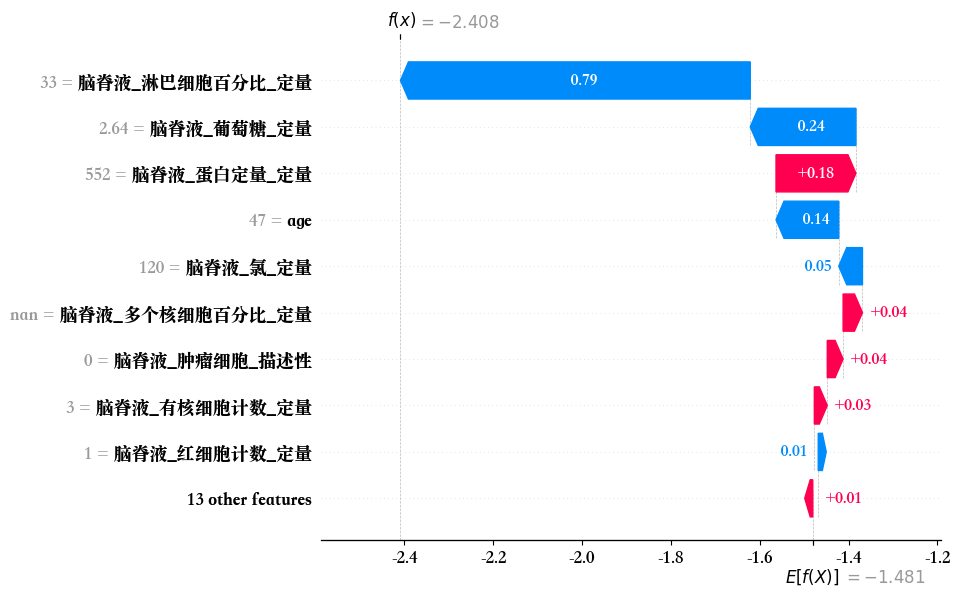

In [7]:
# 生成第一个样本的瀑布图
shap.plots.waterfall(shap.Explanation(values=shap_values[8], 
                                     base_values=explainer.expected_value, 
                                     data=X_test.iloc[8], 
                                     feature_names=X_test.columns))
plt.show()